In [ ]:
!pip install pyspark transformers torch scikit-learn matplotlib pyarrow -q

In [ ]:
# 1. Cài đặt các thư viện lõi
!pip install pyspark transformers torch scikit-learn matplotlib pyarrow -q

# 2. Kết nối Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 3. Kéo dữ liệu từ Drive về ổ SSD nội bộ
# LƯU Ý: Đổi SOURCE_PARQUET cho khớp với đường dẫn thực tế trên Drive của bạn
SOURCE_PARQUET = "/content/drive/MyDrive/images_data.parquet/images_data.parquet"
LOCAL_PARQUET = "/content/images_data_local.parquet"

print("Đang copy dữ liệu sang ổ SSD nội bộ. Vui lòng đợi 1-2 phút...")
!cp -r "$SOURCE_PARQUET" "$LOCAL_PARQUET"
print("✅ Copy hoàn tất! Sẵn sàng cho Spark.")

Mounted at /content/drive
Đang copy dữ liệu sang ổ SSD nội bộ. Vui lòng đợi 1-2 phút...
^C
✅ Copy hoàn tất! Sẵn sàng cho Spark.


In [ ]:
import io
import torch
import pandas as pd
from typing import Iterator
from PIL import Image
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import pandas_udf
from pyspark.sql.types import ArrayType, FloatType
from transformers import CLIPProcessor, CLIPModel

# --- 1. CẤU HÌNH ĐƯỜNG DẪN ---
INPUT_PARQUET = "/content/drive/MyDrive/images_data.parquet/images_data.parquet"
# Lưu file test ra một tên riêng để không ghi đè dữ liệu thật
OUTPUT_PARQUET = "/content/drive/MyDrive/images_data.parquet/output_vectors.parquet"

# --- 2. KHỞI TẠO SPARK (Bảo vệ GPU bằng local[1]) ---
spark = SparkSession.builder \
    .appName("HM_CLIP") \
    .config("spark.driver.memory", "10g") \
    .config("spark.executor.memory", "10g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

# --- 3. ĐỊNH NGHĨA UDF (Chạy Lô siêu tốc) ---
@pandas_udf(ArrayType(FloatType()))
def extract_clip_spark_udf(iterator: Iterator[pd.Series]) -> Iterator[pd.Series]:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model_id = "openai/clip-vit-base-patch32"

    processor = CLIPProcessor.from_pretrained(model_id)
    model = CLIPModel.from_pretrained(model_id).to(device)
    model.eval()

    for image_binaries in iterator:
        batch_images = []
        valid_indices = []

        for idx, img_bytes in enumerate(image_binaries):
            try:
                img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
                batch_images.append(img)
                valid_indices.append(idx)
            except Exception:
                pass # Bỏ qua an toàn những ảnh bị hỏng dữ liệu nhị phân

        batch_size = len(image_binaries)
        features = [[0.0] * 512 for _ in range(batch_size)]

        if batch_images:
            inputs = processor(images=batch_images, return_tensors="pt").to(device)
            with torch.no_grad():
                outputs = model.get_image_features(**inputs)

                # Cơ chế bóc tách an toàn để tương thích mọi phiên bản HuggingFace
                if hasattr(outputs, 'pooler_output'):
                    tensor = outputs.pooler_output
                elif hasattr(outputs, 'image_embeds'):
                    tensor = outputs.image_embeds
                elif isinstance(outputs, tuple):
                    tensor = outputs[0]
                else:
                    tensor = outputs

                vectors = tensor.cpu().numpy().tolist()

                for i, vector in zip(valid_indices, vectors):
                    features[i] = vector

        yield pd.Series(features)

# --- 4. THỰC THI BÀI TEST 200 ẢNH ---
print("📥 Đang nạp toàn bộ danh sách 105.000 sản phẩm...")
images_df = spark.read.parquet(INPUT_PARQUET)

print("🚀 Bắt đầu quá trình Inference trên GPU. Hãy pha một ly cà phê và chờ đợi nhé!")
result_df = images_df.withColumn(
    "clip_vector",
    extract_clip_spark_udf(F.col("content"))
)
final_df = result_df.select("article_id", "clip_vector")

print(f"💾 Đang ghi dần kết quả thẳng xuống: {OUTPUT_PARQUET}")
final_df.write.mode("overwrite").parquet(OUTPUT_PARQUET)

print("🎉 XUẤT SẮC! Đã hoàn thành quá trình tạo Vector cho toàn bộ tập dữ liệu!")

📥 Đang nạp toàn bộ danh sách 105.000 sản phẩm...
🚀 Bắt đầu quá trình Inference trên GPU. Hãy pha một ly cà phê và chờ đợi nhé!
💾 Đang ghi dần kết quả thẳng xuống: /content/drive/MyDrive/images_data.parquet/output_vectors.parquet
🎉 XUẤT SẮC! Đã hoàn thành quá trình tạo Vector cho toàn bộ tập dữ liệu!


In [ ]:
# Đọc lại file Parquet vừa được AI sinh ra
test_result_df = spark.read.parquet("/content/drive/MyDrive/images_data.parquet/output_vectors.parquet")

print("1️⃣ CẤU TRÚC BẢNG DỮ LIỆU:")
test_result_df.printSchema()

print("\n2️⃣ HIỂN THỊ THỬ 20 DÒNG ĐẦU TIÊN:")
test_result_df.show(20, truncate=90)

print(f"\n✅ TỔNG SỐ DÒNG THÀNH CÔNG: {test_result_df.count()} / 200")

1️⃣ CẤU TRÚC BẢNG DỮ LIỆU:
root
 |-- article_id: string (nullable = true)
 |-- clip_vector: array (nullable = true)
 |    |-- element: float (containsNull = true)


2️⃣ HIỂN THỊ THỬ 20 DÒNG ĐẦU TIÊN:
+----------+------------------------------------------------------------------------------------------+
|article_id|                                                                               clip_vector|
+----------+------------------------------------------------------------------------------------------+
|0647338014|[4.813373E-4, -0.27969787, 0.41276705, -0.007630445, -0.3649503, 0.41268778, 0.00369957...|
|0696791001|[0.023914948, 0.15973502, 0.26976797, -0.11391884, -0.4414738, -0.06306591, 0.12074107,...|
|0740790005|[0.0628619, -0.043062285, -0.12015404, -0.15421093, -0.2232342, 0.058231086, 0.10316042...|
|0749968003|[0.06882405, -0.056645304, 0.54129094, 0.118347466, 0.22014341, 0.31021842, -0.02967919...|
|0848974001|[-0.26794946, -0.10282987, 0.2699688, -0.20116283, -0.161479

In [ ]:
import numpy as np
import io
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity

# 1. ĐỌC "CUỐN TỪ ĐIỂN" BẠN VỪA TẠO (Thay vì đọc ảnh)
print("Đang tải dữ liệu Vector...")
vector_df = spark.read.parquet("/content/drive/MyDrive/images_data.parquet/output_vectors.parquet").toPandas()

# 2. CHUẨN BỊ DỮ LIỆU ĐỂ SO SÁNH
article_ids = vector_df['article_id'].tolist()
features_matrix = np.array(vector_df['clip_vector'].tolist())

# (Đoạn này chỉ để lấy lại hình ảnh gốc để vẽ lên màn hình cho bạn xem)
images_df_pd = images_df.toPandas()
binary_dict = dict(zip(images_df_pd['article_id'], images_df_pd['content']))

# 3. HÀM TÌM KIẾM SẢN PHẨM TƯƠNG TỰ
def find_similar_items(query_index, top_k=4):
    # Lấy vector của sản phẩm truy vấn từ trong Bảng ra
    query_vector = features_matrix[query_index].reshape(1, -1)

    # Tính toán Cosine Similarity siêu tốc giữa 1 vector và 199 vector còn lại
    sim_scores = cosine_similarity(query_vector, features_matrix)[0]

    # Xếp hạng điểm số từ cao xuống thấp
    top_indices = sim_scores.argsort()[::-1][1:top_k+1]

    # --- VẼ KẾT QUẢ RA MÀN HÌNH ---
    fig, axes = plt.subplots(1, top_k + 1, figsize=(15, 5))

    # Ảnh gốc (Query)
    q_id = article_ids[query_index]
    axes[0].imshow(Image.open(io.BytesIO(binary_dict[q_id])))
    axes[0].set_title(f"ÁO BẠN CHỌN\nID: {q_id}", color='red')
    axes[0].axis('off')

    # Các ảnh gợi ý
    for i, idx in enumerate(top_indices):
        t_id = article_ids[idx]
        score = sim_scores[idx]
        axes[i+1].imshow(Image.open(io.BytesIO(binary_dict[t_id])))
        axes[i+1].set_title(f"Gợi ý {i+1}\nID: {t_id}\nScore: {score:.3f}", color='green')
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()

Đang tải dữ liệu Vector...


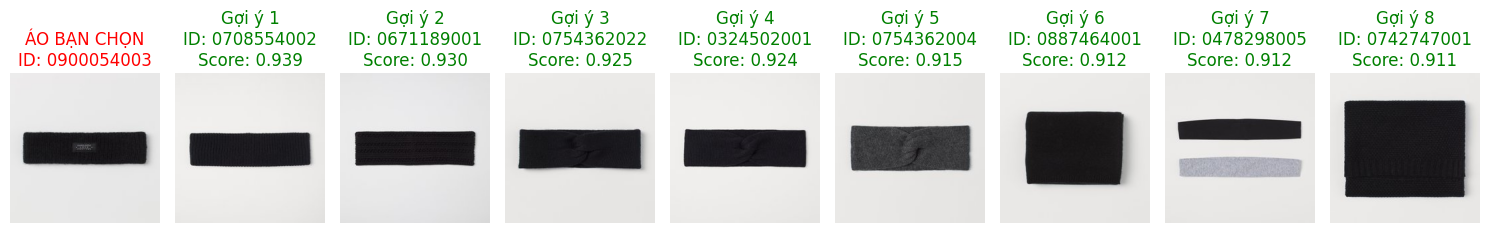

In [ ]:
# Hãy thử tìm đồ giống với sản phẩm số 0 (hoặc thay bằng số 10, 50, 99...)
find_similar_items(query_index=100000, top_k=5)